# HAR-RV-X (Final), Daily Resolution
Same model, same 6 regressors, same methodology as the hourly capstone notebook's kept model (`capstone-btc-volatility.ipynb`) - rebuilt at **daily** resolution instead of hourly, to see whether the model, the ceiling, and the finding all hold up at a coarser timescale.

**What changes vs. the hourly version, and why:**
- Realized volatility is computed the standard way for daily-resolution HAR-RV work (Andersen-Bollerslev): the square root of the sum of squared *intraday* (hourly) log returns within each calendar day - genuine daily realized volatility, not a rolling window of daily closes. The hourly data already available (`data/btc_hourly_ohlcv.csv`) is the intraday source used to build it.
- `ROLLING_WINDOW` and `HORIZON` are now in **days**, not hours: 7 days each (same 7-day meaning as the hourly project's 168-hour window, just expressed in the new unit).
- Everything else - the 6 regressors, Ridge + `TimeSeriesSplit` tuning, the chronological 80/20 split, the leakage discipline, the evaluation function - is unchanged in spirit from the hourly notebook's kept model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

RANDOM_STATE = 42
ROLLING_WINDOW = 7   # 7 DAYS (vs. 168 HOURS in the hourly notebook) - same "1 week" meaning
HORIZON = ROLLING_WINDOW  # forecast 7 days ahead - identical non-overlapping-window logic
CSV_PATH = '../data/btc_hourly_ohlcv.csv'  # same raw source as the hourly notebook

print(f'ROLLING_WINDOW = {ROLLING_WINDOW} days, HORIZON = {HORIZON} days ahead')

ROLLING_WINDOW = 7 days, HORIZON = 7 days ahead


## 1. Build Genuine Daily Realized Volatility From Intraday (Hourly) Returns
Daily OHLCV alone (one row per day) has no intraday information to measure a day's *own* volatility from - a single close-to-close return per day only says how far price moved from open to close, not how much it moved *within* the day. The standard fix (Andersen & Bollerslev, 1998, and the basis for the HAR-RV literature this whole project builds on) is to compute realized volatility from higher-frequency returns and aggregate up: here, hourly log returns within each calendar day.

$$RV_t = \sqrt{\sum_{i=1}^{n_t} r_{i,t}^2}$$

where $r_{i,t}$ is the $i$-th hourly log return on day $t$, and $n_t$ is however many hourly observations that day actually has (24, ordinarily).

In [2]:
df_hourly = pd.read_csv(CSV_PATH, parse_dates=['Date']).sort_values('Date').reset_index(drop=True)
df_hourly['log_return'] = np.log(df_hourly['Close'] / df_hourly['Close'].shift(1))
df_hourly['day'] = df_hourly['Date'].dt.floor('D')

# Genuine daily realized volatility: sqrt(sum of squared hourly log returns within the day)
daily_rv = df_hourly.groupby('day')['log_return'].apply(lambda r: np.sqrt((r.dropna() ** 2).sum()))
daily_rv.name = 'RV'

# Daily OHLCV bars, aggregated from the same hourly source
daily_ohlcv = df_hourly.set_index('Date').resample('1D').agg(
    {'Open': 'first', 'High': 'max', 'Low': 'min', 'Close': 'last', 'Volume': 'sum'}
).dropna()
daily_ohlcv.index.name = 'day'

df = daily_ohlcv.join(daily_rv).dropna().reset_index()
df['daily_return'] = df['Close'].pct_change()

print(f'Daily rows: {len(df)}   Date range: {df["day"].min().date()} to {df["day"].max().date()}')
df.head()

Daily rows: 3059   Date range: 2017-08-17 to 2025-12-31


,day,Open,High,Low,Close,Volume,RV,daily_return
0,2017-08-17,4261.48,4485.39,4200.74,4285.08,795.150377,0.045237,NaN
1,2017-08-18,4285.08,4371.52,3938.77,4108.37,1199.888264,0.057490,-0.041238
2,2017-08-19,4108.37,4184.69,3850.00,4139.98,381.309763,0.064326,0.007694
3,2017-08-20,4120.98,4211.08,4032.62,4086.29,467.083022,0.037428,-0.012969
4,2017-08-21,4069.13,4119.62,3911.79,4016.00,691.743060,0.054346,-0.017201


## 2. Feature Engineering - The Same 6 Regressors, at Daily Resolution
Directly parallels the hourly notebook's kept HAR-RV-X (Final) feature set:
- **RV_day / RV_week / RV_month** - realized volatility over the past day / week (7d) / month (30d) - the HAR (Corsi 2009) multi-horizon structure
- **ATR_X** - Average True Range as a % of price (same scale-fix as the hourly notebook's `atr_pct`)
- **EWMA_X** - EWMA-smoothed volatility, decay factor tuned via `TimeSeriesSplit`
- **SKEW_X** - realized skewness of daily returns over the past week

Every regressor is lagged so the model only ever sees information from *before* the day it's predicting from - identical discipline to the hourly notebook.

In [3]:
# ATR (True Range) as a % of price - same fix as the hourly notebook's atr_pct
prev_close = df['Close'].shift(1)
true_range = pd.concat([
    df['High'] - df['Low'], (df['High'] - prev_close).abs(), (df['Low'] - prev_close).abs()
], axis=1).max(axis=1)
df['ATR_X'] = (true_range / df['Close']).shift(1)

# HAR horizons: past day / week / month realized volatility
df['RV_day'] = df['RV'].shift(1)
df['RV_week'] = df['RV'].shift(1).rolling(ROLLING_WINDOW).mean()
df['RV_month'] = df['RV'].shift(1).rolling(30).mean()

# Realized skewness of daily returns over the past week
df['SKEW_X'] = df['daily_return'].rolling(ROLLING_WINDOW).skew().shift(1)

print('Feature preview:')
df[['day', 'RV', 'RV_day', 'RV_week', 'RV_month', 'ATR_X', 'SKEW_X']].tail()

Feature preview:


,day,RV,RV_day,RV_week,RV_month,ATR_X,SKEW_X
3054,2025-12-27,0.004892,0.030296,0.015809,0.021658,0.033337,-1.637414
3055,2025-12-28,0.004839,0.004892,0.015960,0.021368,0.008318,-1.337021
3056,2025-12-29,0.023348,0.004839,0.014426,0.020742,0.007433,-1.299104
3057,2025-12-30,0.013337,0.023348,0.015246,0.021154,0.041262,-0.584238
3058,2025-12-31,0.012641,0.013337,0.014228,0.021131,0.028867,0.519036


### EWMA_X: tuning the decay factor
Same RiskMetrics-style recursion as the hourly notebook's EWMA model, `σ²ₜ = λσ²ₜ₋₁ + (1-λ)r²ₜ₋₁` - tuned by minimizing RMSE against the actual `RV` series via `TimeSeriesSplit`, not guessed.

In [4]:
def ewma_sigma(returns, lam):
    """Recursive EWMA volatility, one-step-ahead (uses only returns up to t-1 for sigma[t])."""
    var = np.full(len(returns), np.nan)
    returns = returns.values
    first_valid = np.argmax(~np.isnan(returns))
    var[first_valid] = returns[first_valid] ** 2
    for t in range(first_valid + 1, len(returns)):
        if np.isnan(returns[t - 1]):
            var[t] = var[t - 1]
        else:
            var[t] = lam * var[t - 1] + (1 - lam) * returns[t - 1] ** 2
    return np.sqrt(var)

lambda_grid = np.arange(0.85, 0.999, 0.01)
tscv_ewma = TimeSeriesSplit(n_splits=5)
returns_arr = df['daily_return'].fillna(0)

best_lambda, best_rmse = None, np.inf
for lam in lambda_grid:
    sigma = pd.Series(ewma_sigma(returns_arr, lam), index=df.index)
    fold_rmses = []
    for tr_idx, val_idx in tscv_ewma.split(df):
        valid = df['RV'].iloc[val_idx].notna() & sigma.iloc[val_idx].notna()
        if valid.sum() == 0:
            continue
        fold_rmses.append(np.sqrt(mean_squared_error(df['RV'].iloc[val_idx][valid], sigma.iloc[val_idx][valid])))
    mean_rmse = np.mean(fold_rmses)
    if mean_rmse < best_rmse:
        best_lambda, best_rmse = lam, mean_rmse

print(f'Best EWMA lambda: {best_lambda:.3f}  (mean CV RMSE={best_rmse:.6f})')
df['EWMA_X'] = pd.Series(ewma_sigma(returns_arr, best_lambda), index=df.index).shift(1)

Best EWMA lambda: 0.850  (mean CV RMSE=0.015239)


## 3. Target: Average Daily Realized Volatility, 7 Days Ahead
Same non-overlapping-window logic as the hourly notebook: the target is the average `RV` over the *next* 7 days (days t+1 through t+7) - not a single noisy day, and not overlapping with the 7-day window `RV_week` already looks *backward* over. `rolling(7).mean().shift(-7)` computes exactly this: a trailing 7-day average anchored 7 days in the future, shifted back onto today's row.

In [5]:
df['target'] = df['RV'].rolling(ROLLING_WINDOW).mean().shift(-HORIZON)

har_cols = ['RV_day', 'RV_week', 'RV_month', 'ATR_X', 'EWMA_X', 'SKEW_X']
df_model = df.dropna(subset=har_cols + ['target']).reset_index(drop=True)
print(f'Model-ready rows: {len(df_model)}')

# Chronological 80/20 split - never shuffled, same rule as every model in the hourly notebook
split_idx = int(len(df_model) * 0.8)
train, test = df_model.iloc[:split_idx], df_model.iloc[split_idx:]
print(f'Train: {len(train)} days ({train["day"].iloc[0].date()} to {train["day"].iloc[-1].date()})')
print(f'Test:  {len(test)} days ({test["day"].iloc[0].date()} to {test["day"].iloc[-1].date()})')

Model-ready rows: 3022
Train: 2417 days (2017-09-16 to 2024-04-28)
Test:  605 days (2024-04-29 to 2025-12-24)


## 4. Fit HAR-RV-X (Final): Ridge, Alpha Tuned via TimeSeriesSplit

In [6]:
ridge_grid = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}
tscv = TimeSeriesSplit(n_splits=5)

search = GridSearchCV(Ridge(random_state=RANDOM_STATE), ridge_grid, cv=tscv,
                       scoring='neg_root_mean_squared_error', n_jobs=-1)
search.fit(train[har_cols], train['target'])
best_model = search.best_estimator_
print(f'Best alpha: {search.best_params_}')

pred = best_model.predict(test[har_cols])

coefs = pd.Series(best_model.coef_, index=har_cols).sort_values(key=abs, ascending=False)
print('\nRegressor coefficients:')
print(coefs)

Best alpha: {'alpha': 0.1}

Regressor coefficients:
RV_month    0.315989
RV_week     0.208546
RV_day      0.080895
EWMA_X      0.057998
ATR_X       0.056620
SKEW_X     -0.000658
dtype: float64


## 5. Evaluate — Against Naive Persistence, Same Bar As Every Model in This Project

In [7]:
def evaluate(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true.replace(0, np.nan))) * 100
    print(f'{label:28s} RMSE={rmse:.6f}  MAE={mae:.6f}  R2={r2:.4f}  MAPE={mape:.2f}%')
    return {'Model': label, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE': mape}

results = []
results.append(evaluate(test['target'], pred, 'HAR-RV-X (Final, daily)'))

# Naive persistence: most recently known RV, held constant across the forecast horizon -
# same fair-comparison rule used throughout the hourly notebook
naive_pred = pd.Series(train['RV_day'].iloc[-1], index=test.index)
results.append(evaluate(test['target'], naive_pred, 'Naive Persistence'))

results_df = pd.DataFrame(results)
results_df

HAR-RV-X (Final, daily)      RMSE=0.006622  MAE=0.005361  R2=0.1010  MAPE=26.63%
Naive Persistence            RMSE=0.007307  MAE=0.005304  R2=-0.0945  MAPE=23.40%


,Model,RMSE,MAE,R2,MAPE
0,"HAR-RV-X (Final, daily)",0.006622,0.005361,0.100966,26.631915
1,Naive Persistence,0.007307,0.005304,-0.094532,23.399665


## 6. Predicted vs. Actual

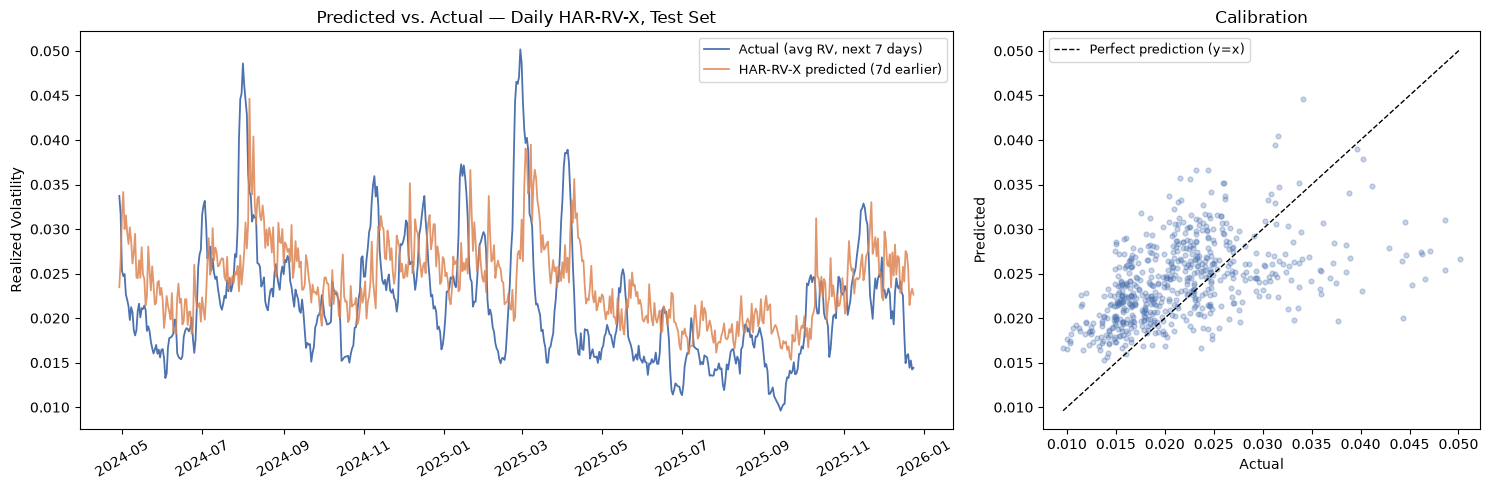

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [2, 1]})

axes[0].plot(test['day'], test['target'], label='Actual (avg RV, next 7 days)', color='#4C72B0', linewidth=1.3)
axes[0].plot(test['day'], pred, label=f'HAR-RV-X predicted ({HORIZON}d earlier)', color='#DD8452', linewidth=1.3, alpha=0.85)
axes[0].set_ylabel('Realized Volatility')
axes[0].set_title('Predicted vs. Actual — Daily HAR-RV-X, Test Set')
axes[0].legend(fontsize=9)
axes[0].tick_params(axis='x', rotation=30)

lims = [min(test['target'].min(), pred.min()), max(test['target'].max(), pred.max())]
axes[1].scatter(test['target'], pred, alpha=0.3, s=12, color='#4C72B0')
axes[1].plot(lims, lims, 'k--', linewidth=1, label='Perfect prediction (y=x)')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
axes[1].set_title('Calibration')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## Conclusion
Same model (HAR-RV-X, 6 regressors: RV_day/week/month, ATR_X, EWMA_X, SKEW_X), same Ridge + `TimeSeriesSplit` tuning, same chronological-split and no-leakage discipline as the hourly notebook's kept model - rebuilt at daily resolution using genuine intraday-derived realized volatility rather than hourly rolling windows.

Compare the R² printed above against the hourly notebook's HAR-RV-X (Final): historical R²=0.242, live R²=0.178. This daily version has a much smaller sample (~3,000 days vs. ~73,000 hours) and a coarser, noisier per-day RV estimate (built from only ~24 intraday observations per day, vs. many more effective observations feeding the hourly project's smoother rolling-window target) - both are real reasons to expect this version's R² to differ from the hourly one, not evidence of a better or worse *model*.